In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.titleweight": "bold"})
BLUE, ORANGE, GREEN, GREY = "#1f6feb", "#fb8500", "#2a9d8f", "#9aa0a6"
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"; IMG = ROOT / "images" / "partC"; IMG.mkdir(parents=True, exist_ok=True)
MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)

TARGET, REFERENCE = "total load actual", "total load forecast"
data = pd.read_csv(PROC / "trackA_features.csv", parse_dates=["time"])
FEATURES = [c for c in data.columns if c not in ("time", TARGET, REFERENCE)]
year = data["time"].dt.year
train, val, test = data[year <= 2016], data[year == 2017], data[year == 2018]
X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAPE_%": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)}

print(len(FEATURES), "features | train/val/test:", len(train), len(val), len(test))

19 features | train/val/test: 17328 8758 8757


## 0. The models we will use, in plain words
A model learns a function from the features to the demand: it sees many examples (features to demand) and finds the pattern that links them.

- **Ridge, a linear model.** It predicts demand as a weighted sum of the features: demand is roughly w1 * feature1 + w2 * feature2 + ... Each weight says how strongly a feature pushes demand up or down. Ridge adds a small penalty on large weights so it does not overfit. It is transparent (you can read the weights), but it needs the features on comparable scales, which is why it sits in a pipeline with a scaler.
- **Decision tree.** It asks a cascade of yes/no questions on the features (is hour above 18? is temperature above 25?) and predicts the average demand in each final group. It captures non-linear effects and interactions on its own, and needs no scaling.
- **Gradient boosting, HistGradientBoosting and XGBoost.** Hundreds of small trees in sequence, each one correcting the errors of the previous ones. It is the strong default for tabular data, and the reason the tree models beat the linear one here.

We train one linear model and one boosting model, then compare them to the baselines.

## 1. Ridge, a transparent linear model
Ridge needs scaling, so it lives in a pipeline (imputer, scaler, Ridge) fitted on train only

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge = Pipeline([("imputer", SimpleImputer(strategy="median")),
                  ("scaler", StandardScaler()),
                  ("model", Ridge(alpha=1.0))])
ridge.fit(X_train, y_train)
print("Ridge val:", {k: round(v, 2) for k, v in evaluate(y_val, ridge.predict(X_val)).items()})

Ridge val: {'MAE': 2051.74, 'RMSE': 2760.43, 'MAPE_%': 7.21}


## Look inside Ridge: it is a weighted sum
Ridge learned one weight per feature. On the scaled features, a large positive weight means the feature pushes demand up, a large negative weight pulls it down. This is what "linear and transparent" means: we can read the model directly.

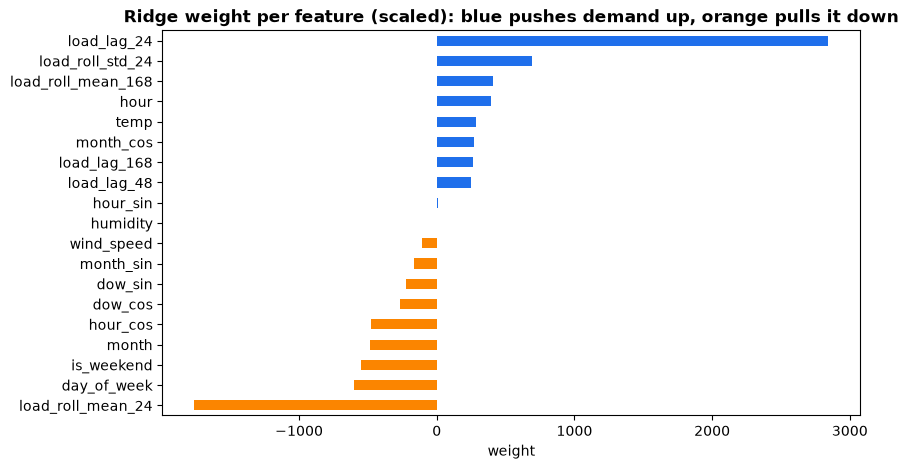

In [5]:
coefs = pd.Series(ridge.named_steps["model"].coef_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
coefs.plot.barh(ax=ax, color=[ORANGE if c < 0 else BLUE for c in coefs])
ax.set_title("Ridge weight per feature (scaled): blue pushes demand up, orange pulls it down")
ax.set_xlabel("weight")
fig.savefig(IMG / "ridge_coefficients.png", dpi=130, bbox_inches="tight"); plt.show()

## 2. HistGradientBoosting, a non-linear tabular model
Trees capture non-linear effects (the temperature curve).

In [6]:
from sklearn.ensemble import HistGradientBoostingRegressor
hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train, y_train)
print("HistGB val:", {k: round(v, 2) for k, v in evaluate(y_val, hgb.predict(X_val)).items()})

HistGB val: {'MAE': 1741.57, 'RMSE': 2515.11, 'MAPE_%': 6.12}


## Look inside a tree: the questions it asks
A boosting model stacks hundreds of small trees. Here is ONE shallow tree so you can see how a tree works: each box is a yes/no question on a feature (for example, is load_lag_24 below some value?), the data goes left or right, and each leaf predicts the average demand of the examples that reached it. The full model asks such questions hundreds of times and adds up the answers.

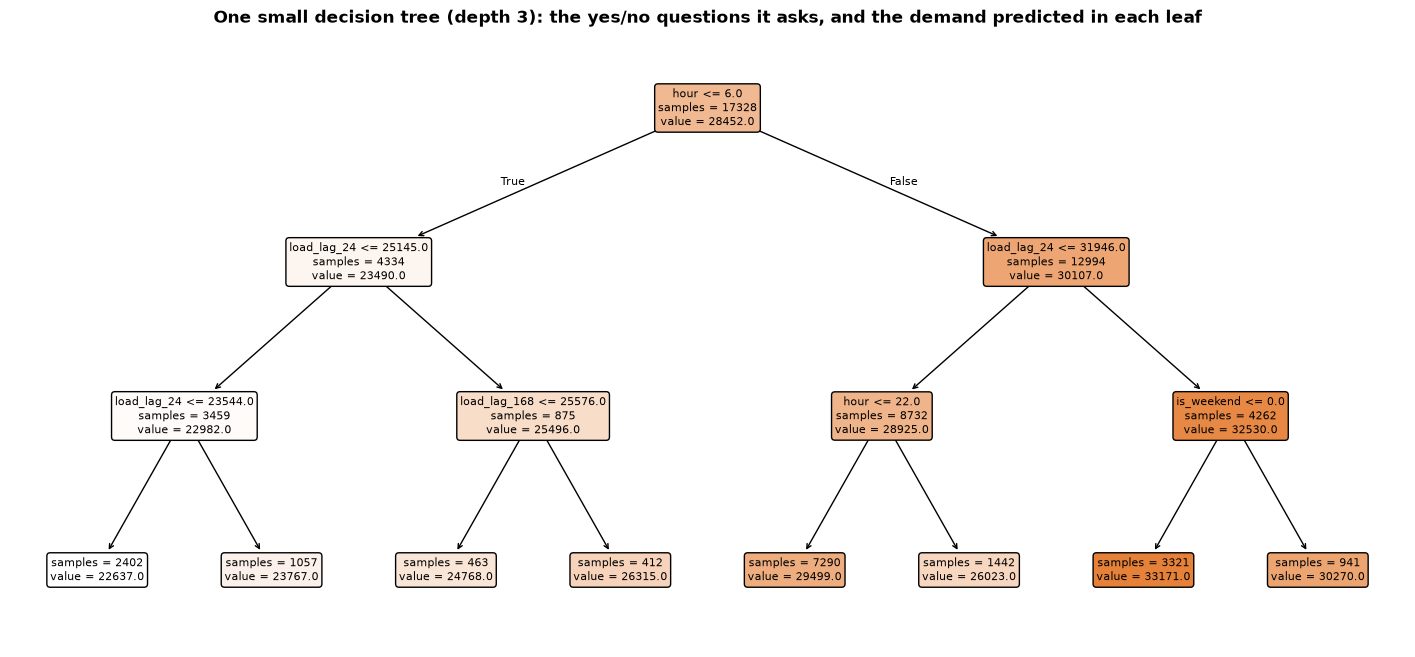

In [7]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
demo_tree = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(demo_tree, feature_names=FEATURES, filled=True, rounded=True,
          impurity=False, precision=0, fontsize=8, ax=ax)
ax.set_title("One small decision tree (depth 3): the yes/no questions it asks, and the demand predicted in each leaf")
fig.savefig(IMG / "decision_tree.png", dpi=130, bbox_inches="tight"); plt.show()

## 3. Optional extension: XGBoost
Same idea as HistGB, a strong gradient boosting library. Its settings play the same roles: n_estimators, the number of trees; learning_rate, the step size; max_depth, the tree depth; and subsample / colsample_bytree, which add a bit of randomness to avoid overfitting. We chose reasonable values but did not tune them; tuning is the next step.

In [8]:
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                       subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1)
    xgb.fit(X_train, y_train)
    print("XGBoost val:", {k: round(v, 2) for k, v in evaluate(y_val, xgb.predict(X_val)).items()})
except ImportError:
    xgb = None
    print("xgboost not installed: skipping the optional extension")

XGBoost val: {'MAE': 1721.36, 'RMSE': 2503.42, 'MAPE_%': 6.03}


## 4. Final comparison on the untouched test year
The 2018 test set is used once, here. Baselines, reference, and models in one honest table.

In [9]:
ref = test.dropna(subset=[REFERENCE])
rows = [
    {"model": "Naive: same hour yesterday",   **evaluate(y_test, test["load_lag_24"])},
    {"model": "Naive: same hour last week",   **evaluate(y_test, test["load_lag_168"])},
    {"model": "Provided forecast (reference)", **evaluate(ref[TARGET], ref[REFERENCE])},
    {"model": "Ridge",                         **evaluate(y_test, ridge.predict(X_test))},
    {"model": "HistGradientBoosting",          **evaluate(y_test, hgb.predict(X_test))},
]
if xgb is not None:
    rows.append({"model": "XGBoost", **evaluate(y_test, xgb.predict(X_test))})
results = pd.DataFrame(rows).set_index("model").round(2)
results

,MAE,RMSE,MAPE_%
model,,,
Naive: same hour yesterday,2519.40,3606.85,8.72
Naive: same hour last week,2642.76,3811.03,9.12
Provided forecast (reference),269.80,389.29,0.93
Ridge,2026.06,2726.46,7.01
HistGradientBoosting,1743.99,2553.82,5.99
XGBoost,1750.62,2591.25,5.98


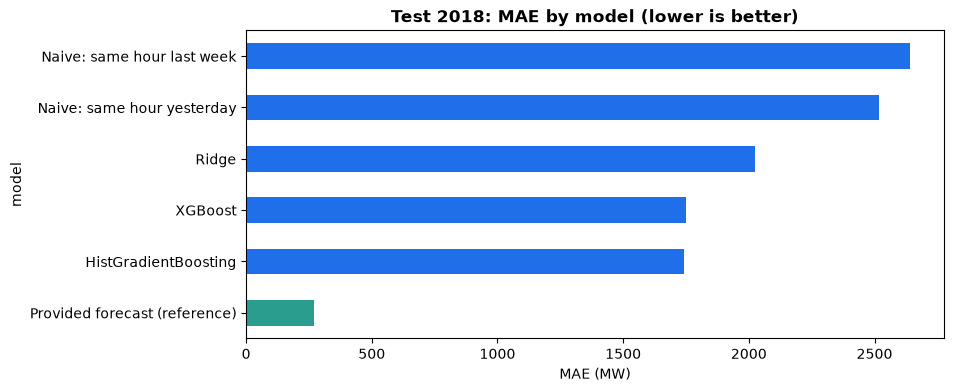

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
results["MAE"].sort_values(ascending=True).plot.barh(ax=ax, color=[GREEN]+[BLUE]*(len(results)-1))
ax.set_title("Test 2018: MAE by model (lower is better)"); ax.set_xlabel("MAE (MW)")
fig.savefig(IMG / "results_mae.png", dpi=130, bbox_inches="tight"); plt.show()

Both trained machine learning models significantly outperform the naive baselines.
The best model (HistGradientBoosting, MAE $1,743.99\text{ MW}$) still lags behind the official provided TSO forecast reference (MAE $269.80\text{ MW}$, MAPE $0.93\%$).
Proving that machine learning substantially beats naive persistence baselines (from $8.72\%$ down to $5.99\%$) demonstrates that our feature engineering and modeling pipeline successfully captured the underlying demand patterns.

## 5. Look at the forecasts, not only the scores
One test week, actual vs predicted, then the residual distribution.

best on validation: XGBoost


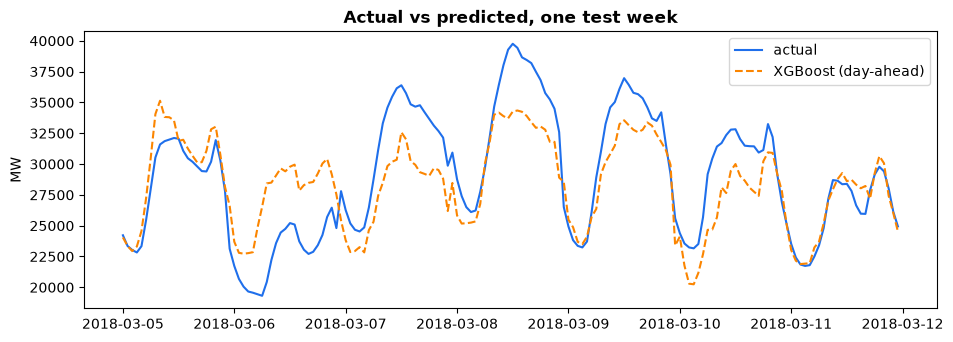

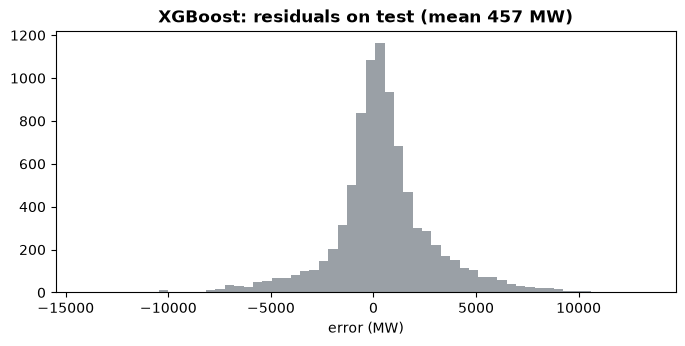

In [11]:
best_name, best_model = min(
    [("Ridge", ridge), ("HistGradientBoosting", hgb)] + ([("XGBoost", xgb)] if xgb is not None else []),
    key=lambda kv: evaluate(y_val, kv[1].predict(X_val))["MAE"])
print("best on validation:", best_name)

wk = test[(test["time"] >= "2018-03-05") & (test["time"] < "2018-03-12")]
fig, ax = plt.subplots()
ax.plot(wk["time"], wk[TARGET], color=BLUE, label="actual")
ax.plot(wk["time"], best_model.predict(wk[FEATURES]), color=ORANGE, ls="--", label=f"{best_name} (day-ahead)")
ax.set_title("Actual vs predicted, one test week"); ax.set_ylabel("MW"); ax.legend()
fig.savefig(IMG / "pred_week.png", dpi=130, bbox_inches="tight"); plt.show()

resid = y_test - best_model.predict(X_test)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(resid, bins=60, color=GREY)
ax.set_title(f"{best_name}: residuals on test (mean {resid.mean():.0f} MW)"); ax.set_xlabel("error (MW)")
fig.savefig(IMG / "residuals.png", dpi=130, bbox_inches="tight"); plt.show()

## 6. XAI core: permutation importance
Shuffle one feature at a time; if the score drops, the model relied on it.

<Axes: >

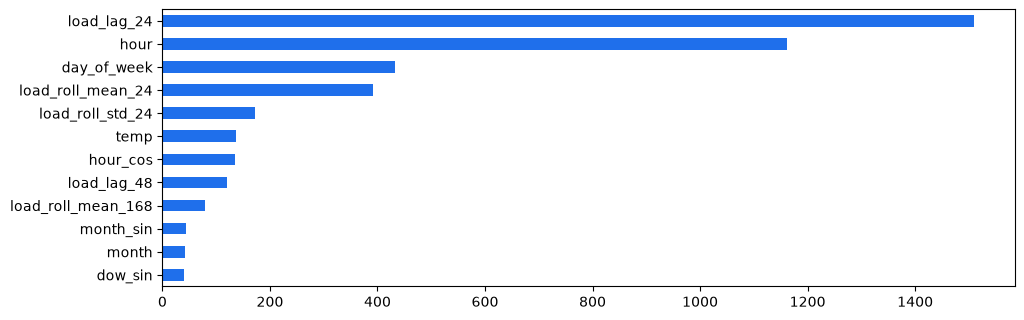

In [12]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(best_model, X_val, y_val, n_repeats=5, random_state=42, scoring="neg_mean_absolute_error")   # TODO: permutation_importance(best_model, X_val, y_val, n_repeats=5, random_state=42, scoring="neg_mean_absolute_error")
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
imp.tail(12).plot.barh(color="#1f6feb")

## 8. Export for the backend
The FastAPI backend must reload the model, never retrain it. We save the model, the feature list and metadata together.

In [13]:
artifact = {"model": best_model, "model_name": best_name, "features": FEATURES,
            "target": TARGET, "horizon": "t+24 (day-ahead)",
            "test_metrics": results.loc[best_name].to_dict(),
            "weather_assumption": "observed weather at target hour used as a day-ahead forecast proxy"}
joblib.dump(artifact, MODELS / "forecasting_model.joblib")
print("saved:", MODELS / "forecasting_model.joblib")

saved: C:\Users\Lim\PycharmProjects\alice-track-a-team-Lim\models\forecasting_model.joblib
